# Data Preparation

It is important to run this code block before working on the rest of the notebook. Check out the comments to help you understand what each step does.

Refer to the [VCQ code book](https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit) for questions that match the columns in the following dataset.

In [33]:
# Step 1: Collect the original data into a DataFrame object
import pandas as pd
raw_df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv')

# Step 2: Create DataFrame objects to hold only columns from individual sections
# and create section indicators
security_df = raw_df.filter(regex='^jobsecurity').copy()
r_columns = ['jobsecurity_worry', 'jobsecurity_people', 'jobsecurity_challenge']
security_df[r_columns] = 7 - security_df[r_columns]
security_df['security_mean'] = security_df.mean(axis=1)

satisfaction_df = raw_df.filter(regex='^jobsatisfaction').copy()
r_columns = ['jobsatisfaction_waste', 'jobsatisfaction_bored']
satisfaction_df[r_columns] = 7 - satisfaction_df[r_columns]
satisfaction_df['satisfaction_mean'] = satisfaction_df.mean(axis=1)

mobility_df = raw_df.filter(regex='^jobmobility').copy()
r_columns = ['jobmobility_stuck', 'jobmobility_opportunities']
mobility_df[r_columns] = 7 - mobility_df[r_columns]
mobility_df['mobility_mean'] = mobility_df.mean(axis=1)

demand_df = raw_df.filter(regex='^workdemands').copy()
r_columns = ['workdemands_free', 'workdemands_easy']
demand_df[r_columns] = 7 - demand_df[r_columns]
demand_df['demand_mean'] = demand_df.mean(axis=1)

supervisor_df = raw_df.filter(regex='^supervisors').copy()
r_columns = ['supervisors_me', 'supervisors_argue']
supervisor_df[r_columns] = 7 - supervisor_df[r_columns]
supervisor_df['supervisors_mean'] = supervisor_df.mean(axis=1)

# Step 5: Create a new DataFrame to combine section means with demographic data
data = {'age':raw_df['demo_age'].copy(),
        'units': raw_df['demo_units'].copy(),
        'gpa': raw_df['demo_gpa'],
        'employed': raw_df['demo_employed04'],
        'income': raw_df['demo_incomepersonal'],
        'job_security': security_df['security_mean'],
        'job_satisfaction': satisfaction_df['satisfaction_mean'],
        'job_mobility': mobility_df['mobility_mean'],
        'work_demands': demand_df['demand_mean'],
        'relation_supervisors': supervisor_df['supervisors_mean']}
df = pd.DataFrame(data)

# Step 6: focus on students who were in a relationship
condition = (df['employed'] == 1)
df = df[condition]

df.head()

,age,units,gpa,employed,income,job_security,job_satisfaction,job_mobility,work_demands,relation_supervisors
0,19.0,15.0,3.15,1.0,16000.0,5.0,3.4,4.2,4.625,4.666667
1,26.0,14.0,3.30,1.0,27000.0,4.8,4.0,3.2,4.750,4.500000
5,24.0,16.0,3.00,1.0,NaN,3.8,4.2,3.2,5.000,3.166667
6,20.0,17.0,3.25,1.0,9000.0,3.8,3.6,4.4,2.375,4.833333
7,21.0,15.0,2.33,1.0,14400.0,4.2,4.4,4.6,2.500,3.833333


# Scatter plot

As a reminder scatter plots help visualize relationships between two **numerical variables**. The following code block shows how to use the `plot` function to create a scatter plot.

*  Set the `kind` parameter to `'scatter'`.
*  The `x` parameter specifies the column whose values will be used for the x-axis.
*  The `y` parameter specifies the column whose values will be used for the y-axis.
*  The `figsize` parameter specifies the width and height of the figure.
*  The `alpha` parameter specifies the level of transparency for each dot, 0 for fully transparent and 1 for fully opaque. The default value is 1.
*  The `s` parameter specifies the size of the dots, 20 for a small dot, 50 - 80 for a medium dot, and 150 - 300 for a large dot.
*  The `grid` parameter specifies whether to show a grid in the background. The default value is `False`.

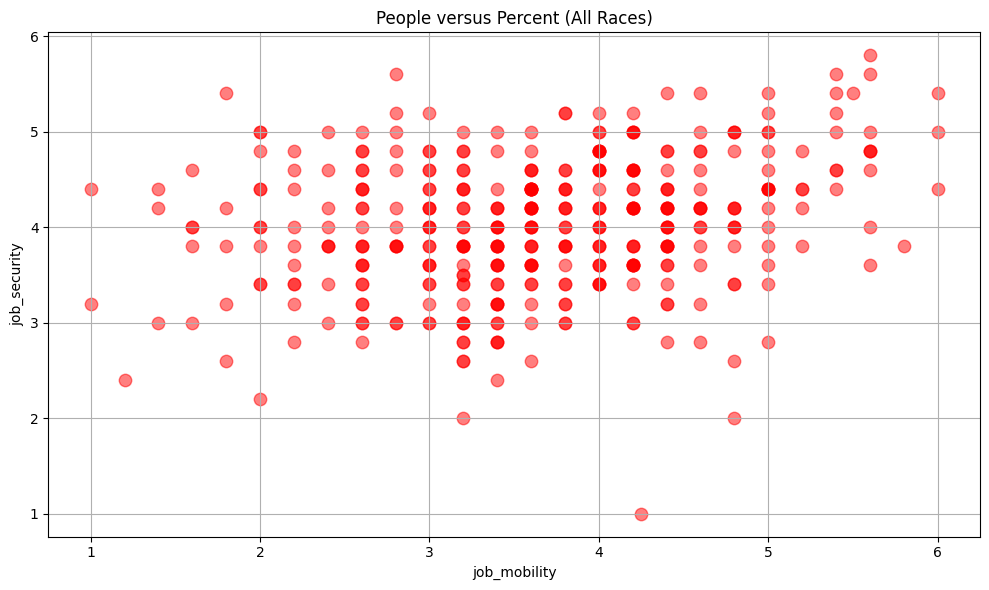

In [34]:
import matplotlib.pyplot as plt     # import appropriate library

# create a scatter plot
df.plot(kind='scatter',             #Indicate the kind of plot to be generated
        y='job_security',            #Identify the column for the x_axis
        x='job_mobility',             #Identify the column for the y-axis
        figsize=(10, 6),             #Set up the width and height of the graph
        title='People versus Percent (All Races)',  #Set up the title of the graph
        s=80,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='red',                #Indicate the color for the dots
        grid=True                   #Decide whether to use grid
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

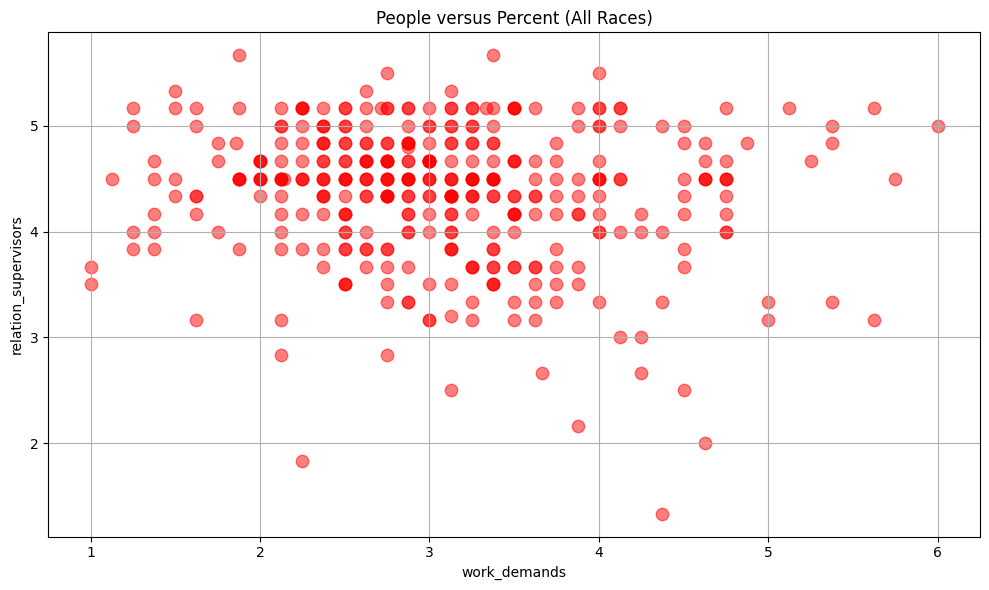

In [36]:
import matplotlib.pyplot as plt     # import appropriate library

# create a scatter plot
df.plot(kind='scatter',             #Indicate the kind of plot to be generated
        y='relation_supervisors',            #Identify the column for the x_axis
        x='work_demands',             #Identify the column for the y-axis
        figsize=(10, 6),             #Set up the width and height of the graph
        title='People versus Percent (All Races)',  #Set up the title of the graph
        s=80,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='red',                #Indicate the color for the dots
        grid=True                   #Decide whether to use grid
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

# Two-way ANOVA

A **one-way ANOVA** test looks at one **independent, categorical** variable and one **dependent, quantitative** variable. It helps determine whether the dependent variable changes according to the categories of the independent variable.

However, complex social phenomena often involve multiple factors. For example,
*  Does class standing affect a student's stress level?
*  Does gender also play a role?
*  Does these two factors interact?

Analyses could be done via a **two-way ANOVA** test that looks at ** TWO independent, categorical** variables and one **dependent, quantitative** variable. For each test, we specify three null hypotheses:

*  Main effect of factor A (e.g. There is no difference of stress among different class standings.)
*  Main effect of factor B (e.g. There is no difference of stress among different genders.)
*  Interaction effect (e.g. The effect of class standing does not depend on gender.)

# Deviance and gender

## boxplot

Previously, we used the `y` parameter in `sns.boxplot` to specify the numeric column and the `x` parameter to specify the first level of grouping. As shown in the following example, we can use the `hue` parameter to specify an additional level of grouping.

The `plt.legend` function allows us to specify the location of the legend box using the `loc` and `bbox_to_anchor` parameters.
* bbox_to_anchor=(x, y)
This defines a point in chart coordinates. Think of this as where you want to attach the legend.
  *  (0, 0) → bottom-left of the chart
  *  (1, 1) → top-right of the chart
  *  (1.02, 1) → slightly outside the chart on the right

* loc
This defines which corner (or edge) of the legend box is attached to that point.
So the legend is placed by:
“Attach this part of the legend (loc) to that point (bbox_to_anchor).”

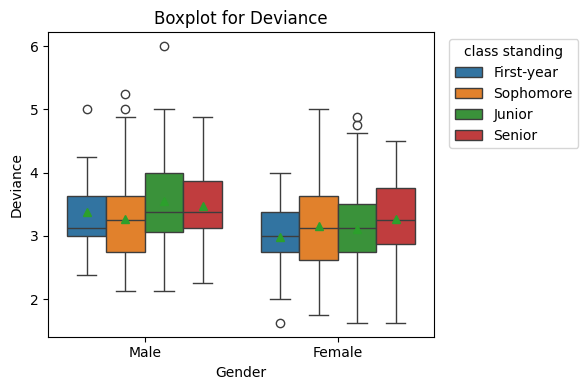

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Gender')

sns.boxplot(data=df,
            y='deviance',
            x='gender',
            hue='classstanding',
            showmeans=True)

plt.legend(title='class standing',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

The above boxplot helps us visualize some variation of deviance among different class standings within each gender.
1.  Within Male students:
  *  The First-year group has the lowest median and smallest IQR (Inter-Quantile Range). Its mean/average is the furthest away from its median.
  *  The Junior group has the highest mean/average and median.
  *  There Sophomore group has the lowest mean/average.
2.  Within the Female students:
  *  The means/averages are more consistent with the medians for all class standings.
  *  The Sophomore group has the highest IQR.
  *  The First-year group has the lowest mean/average.

We can switch the `x` and `hue` parameters in `sns.boxplot` to present the same data in a slightly different view. In that case, we need to also adjust `plt.xlabel` and the `title` parameter for `plt.legend`.

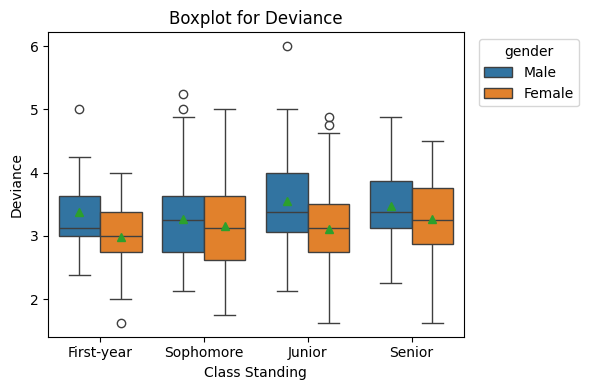

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Class Standing')

sns.boxplot(data=df,
            y='deviance',
            hue='gender',
            x='classstanding',
            showmeans=True)

plt.legend(title='gender',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

The above result helps compare gender groups within each class standing. The First-year and Junior groups have more mean/average difference between male and female students than the Sophomore and Senior groups.

## bar charts

To generate bar charts, we will need to calculate the average within each subgroups. We can do so using `groupby` or `pivot_table`. As a reminder, we need to call the `reset_index` function to make  index into column.

In [ ]:
dev_gc_group = df.groupby(['gender', 'classstanding'], observed=True)['deviance'].mean().reset_index()
dev_gc_group

,gender,classstanding,deviance
0,Female,First-year,2.978741
1,Female,Sophomore,3.161585
2,Female,Junior,3.111919
3,Female,Senior,3.265542
4,Male,First-year,3.375000
5,Male,Sophomore,3.260204
6,Male,Junior,3.546905
7,Male,Senior,3.477106


In [ ]:
dev_gc_pivot = df.pivot_table(values='deviance',
                              index=['gender', 'classstanding'],
                              aggfunc='mean',
                              observed=True).reset_index()
dev_gc_pivot

,gender,classstanding,deviance
0,Female,First-year,2.978741
1,Female,Sophomore,3.161585
2,Female,Junior,3.111919
3,Female,Senior,3.265542
4,Male,First-year,3.375000
5,Male,Sophomore,3.260204
6,Male,Junior,3.546905
7,Male,Senior,3.477106


Similar to the `sns.boxplot` function, the `sns.barplot` function also supports the `hue` parameter to add an additional categorical group.

In the following code block, we set the `x` parameter to `'gender'` and the hue parameter to `'classstanding'`.

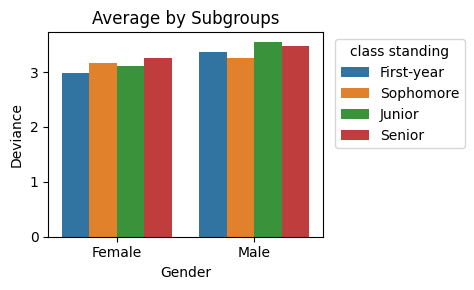

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))
sns.barplot(data=dev_gc_group, y='deviance', x='gender', hue='classstanding')
plt.title('Average by Subgroups')
plt.ylabel('Deviance')
plt.xlabel('Gender')

plt.legend(title='class standing',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


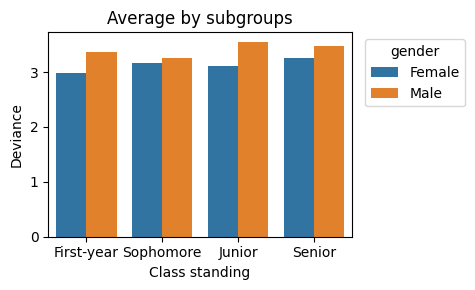

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))
sns.barplot(data=dev_gc_group, y='deviance', hue='gender', x='classstanding')
plt.title('Average by subgroups')
plt.ylabel('Deviance')
plt.xlabel('Class standing')

plt.legend(title='gender',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


## Null Hypotheses

For each test, we specify three null hypotheses:

*  There is no difference of deviance among different genders.
*  There is no difference of deviance among different class standings.
*  The effect of gender on deviance does not depend on class standings.

To perform an ANOVA Test on the above mentioned null hypothesis:
*  `gender` and `classstanding`would be the **independent, categorical** variable
*  `deviance` would be the **dependent, quantitative** variable.

## Perform ANOVA

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

deviance_model = ols(formula='deviance ~ C(gender) + C(classstanding) + C(gender) : C(classstanding)',
                            data=df).fit()
deviance_anova = anova_lm(deviance_model, typ=2)
print(deviance_anova)

                                sum_sq     df          F    PR(>F)
C(gender)                     9.774335    1.0  20.676473  0.000007
C(classstanding)              1.531559    3.0   1.079945  0.357073
C(gender):C(classstanding)    2.597091    3.0   1.831282  0.140398
Residual                    251.018249  531.0        NaN       NaN


## Interprete ANOVA Table

Main Effect: gender

*  p = 0.000007
*  There is a **significant difference** in deviance between genders, averaged across all class standings. Gender matters, regardless of class standing.

Main Effect: classstanding

*  p = 0.36
*  There is **no evidence** that deviance differs by class standing, when averaging across gender. Any observed differences among First-year, sophomore, juniors, and seniors could be reasonably be attributed to random variation.

Interaction: gender x classstanding

*  p = 0.14
**No interaction** → the gender difference is fairly consistent across all class standings. The observed differences in gender gaps across class standings are not large enough, relative to within-group variability, to conclude that the gender effect truly depends on class standing.

**sum_sq**: The sum of squares measure how spread out the data are around the mean/average. ANOVA answers how much of the total variability we can attribute to each source.
*  Gender sum_sq measures how much variability is explained by differences between gender means, ignoring class standing.
*  Class standing sum_sq measures how much variability is explained by differences among class standing means, ignoring gender.
*  Interaction sum_sq measures how much additional variability is explained by allowing the gender effect to differ across class standings.
*  Residual sum_sq indicates how much variability is NOT explained by the model.

From the above result, we can see that residual sum_sq (251) is much larger than the total of the other sum_sq (9.78 + 1.53 + 2.59), inicating that unexplained variability is much larger.

# Practice - family satisfaction by children and another categorical groupfa

## Visualization

In [ ]:
# Visualization #2: Boxplots


In [ ]:
# Visualization #3: Bar charts

**Add a text block** to describe differences among subgroups based on the above visualization.

## Null Hypothesis

State **three null hypothesis** to be tested using ANOVA. Identify the **independent, categorical** variables and the **dependent, quantitative** variable.

## Perform ANOVA

In [ ]:
# Import appropriate modules

# Use the ols function to prepare a linear model.

# Use the anova_lm function to perform the test

# Show the resulting ANOVA table.



## Interprete ANOVA Table

For each null hypothesis, explain whether you accept or reject it and why?

# Reflection

**Add a text block** to discuss your thoughts about the difference between one-way and two-way ANOVA.